In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from classes import Problem, Boat, Trip
import seaborn as sns
# import scikit_posthocs as sp

c:\Users\saahi\Documents\Uni\4th Year\Semester 1\P4P\Ground-Fish-P4P\final_code\data_loader.py:31: SyntaxWarning: invalid escape sequence '\s'
  with open('my_code\sample data\smb.2019.dat') as f:
c:\Users\saahi\Documents\Uni\4th Year\Semester 1\P4P\Ground-Fish-P4P\final_code\data_loader.py:34: SyntaxWarning: invalid escape sequence '\s'
  with open('sample data\smb.2019.dat') as f:
c:\Users\saahi\Documents\Uni\4th Year\Semester 1\P4P\Ground-Fish-P4P\final_code\data_loader.py:57: SyntaxWarning: invalid escape sequence '\s'
  with open('my_code\sample data\RandomMatchingCatches.dat') as f:
c:\Users\saahi\Documents\Uni\4th Year\Semester 1\P4P\Ground-Fish-P4P\final_code\data_loader.py:65: SyntaxWarning: invalid escape sequence '\R'
  with open('sample data\RandomMatchingCatches.dat') as f:


In [2]:
records = []
with open("original_mip_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_mip_orig = pd.DataFrame(records)
df_mip_orig["bound_gap"] = (df_mip_orig["best_obj"]-df_mip_orig["best_bound"])/df_mip_orig["best_bound"]*100
# display(df_mip_orig[df_mip_orig['problem_id'].isin([28, 29, 31])])
# display(df_mip)

<>:51: SyntaxWarning: invalid escape sequence '\%'
<>:52: SyntaxWarning: invalid escape sequence '\%'
<>:51: SyntaxWarning: invalid escape sequence '\%'
<>:52: SyntaxWarning: invalid escape sequence '\%'
C:\Users\saahi\AppData\Local\Temp\ipykernel_2856\915276372.py:51: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel('Objective, relative to 100\% model (\%)', fontsize=16)
C:\Users\saahi\AppData\Local\Temp\ipykernel_2856\915276372.py:52: SyntaxWarning: invalid escape sequence '\%'
  plt.title('Objective for different percentage models, relative to the 100\% model', fontsize=18)
C:\Users\saahi\AppData\Local\Temp\ipykernel_2856\915276372.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  valid_ids = df_mip[df_mip['percentage_kept'] == 100][df_mip['best_obj'] > 0]['problem_id'].unique()


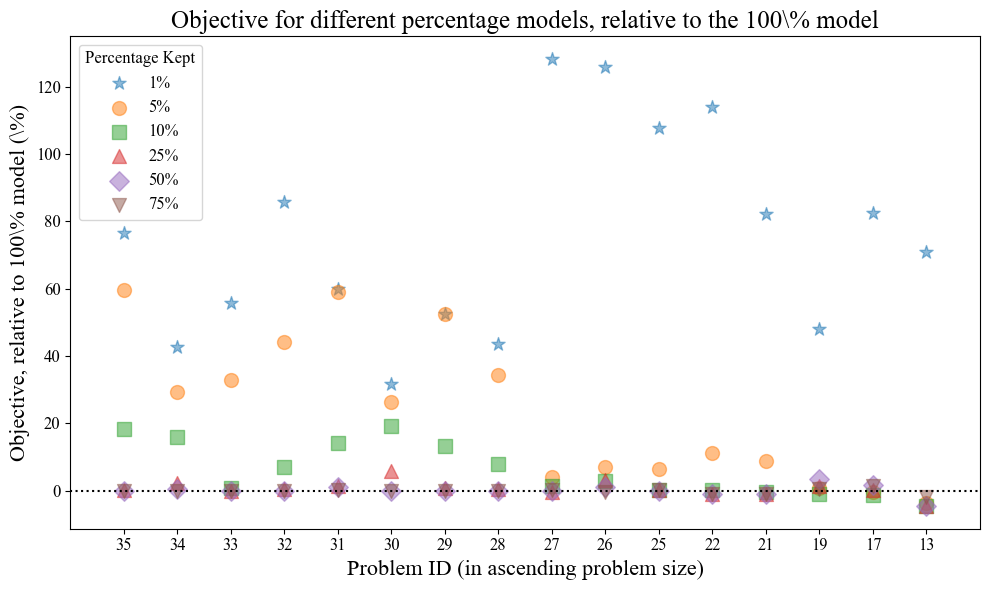

In [3]:
df_mip = df_mip_orig.copy()
df_mip = df_mip[df_mip['percentage_kept'] > 0]
# Filter for problem_ids that have a best_obj for 100% kept
valid_ids = df_mip[df_mip['percentage_kept'] == 100][df_mip['best_obj'] > 0]['problem_id'].unique()
df_plot = df_mip[df_mip['problem_id'].isin(valid_ids)].copy()

# Compute best_obj for 100% kept per problem_id
best_obj_100 = df_plot[df_plot['percentage_kept'] == 100].groupby('problem_id')['best_obj'].min()
df_plot['best_obj_100'] = df_plot['problem_id'].map(best_obj_100)

# Compute relative difference (0 for 100%, >0 for others)
df_plot['relative_obj'] = (df_plot['best_obj'] - df_plot['best_obj_100']) / df_plot['best_obj_100'] * 100
df_plot.loc[df_plot['percentage_kept'] == 100, 'relative_obj'] = 0

# Define marker shapes for each percentage_kept value
percentages = sorted(df_plot['percentage_kept'].unique())
markers = ['*', 'o', 's', '^', 'D', 'v', 'P', 'X'] # 6 shapes

df_plot['problem_id'] = df_plot['problem_id'].astype(str)

# plt.rcParams.update({
#     "text.usetex": True,     # enables LaTeX rendering
#     "font.family": "serif",    # use a serif font
#     "font.serif": ["Computer Modern"]  # closest to Overleaf
# })
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})
plt.figure(figsize=(10, 6))
for perc, marker in zip(percentages, markers):
    if perc == 100:
        continue
    subset = df_plot[df_plot['percentage_kept'] == perc]
    plt.scatter(
        subset['problem_id'],
        subset['relative_obj'],
        marker=marker,
        s=100,
        label=f'{perc}%',
        alpha=0.5
    )
    # print(f'{perc}: {subset['relative_obj'].values}')
# plt.yscale('log')
plt.hlines(0, -1, 16, linestyles='dotted', colors='black', alpha=1)
plt.xlim([-1, 16])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Problem ID (in ascending problem size)', fontsize=16)
plt.ylabel('Objective, relative to 100\% model (\%)', fontsize=16)
plt.title('Objective for different percentage models, relative to the 100\% model', fontsize=18)
plt.legend(title='Percentage Kept', loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

<>:83: SyntaxWarning: invalid escape sequence '\%'
<>:84: SyntaxWarning: invalid escape sequence '\%'
<>:83: SyntaxWarning: invalid escape sequence '\%'
<>:84: SyntaxWarning: invalid escape sequence '\%'
C:\Users\saahi\AppData\Local\Temp\ipykernel_2856\1083848989.py:83: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel("Time saved, relative to the 100\% model (min)", fontsize=16)
C:\Users\saahi\AppData\Local\Temp\ipykernel_2856\1083848989.py:84: SyntaxWarning: invalid escape sequence '\%'
  plt.title("Time saved to find a solution within 5\% of the 100\% model's best objective", fontsize=18)


60


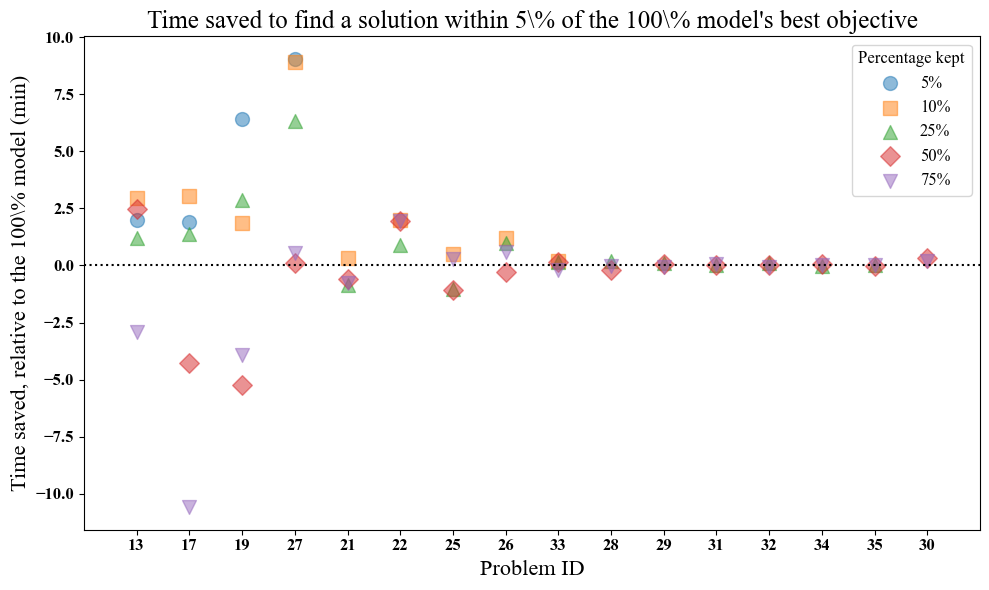

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# assume df has columns: problem_id, percentage_kept, best_obj, solution_log (list of (time, incumbent, bound))

results = []
df = df_mip_orig.copy()

count = 0
for pid, group in df.groupby('problem_id'):
    # --- Find the best objective from 100% kept ---
    ref_row = group[group['percentage_kept'] == 100]
    if ref_row.empty:
        continue
    best_obj_100 = ref_row['best_obj'].values[0]*1.05
    
    # Get time when 100% kept reached this best objective
    log_100 = eval(ref_row['solution_log'].values[0])
    # print(log_100)
    time_100 = None
    for t, inc, _ in log_100:
        if inc <= best_obj_100:
            time_100 = t
            break

    if time_100 is None:
        continue

    # Add reference point (optional)
    # results.append({
    #     'problem_id': pid,
    #     'percentage_kept': 100,
    #     'time': time_100 - time_100
    # })

    # --- For other percentages ---
    for perc, sub in group[group['percentage_kept'] != 100].groupby('percentage_kept'):
        log = eval(sub['solution_log'].values[0])
        time_found = None
        for t, inc, _ in log:
            if inc <= best_obj_100:
                time_found = t
                break
        if time_found is not None:
            results.append({
                'problem_id': pid,
                'percentage_kept': perc,
                'time': (time_100 - time_found)/60
            })
            count += 1
print(count)


# Convert to dataframe for plotting
plot_df = pd.DataFrame(results)
plot_df['problem_id'] = plot_df['problem_id'].astype(str)

# --- Plot ---
# plt.rcParams.update({
#     "text.usetex": True,     # enables LaTeX rendering
#     "font.family": "serif",    # use a serif font
#     "font.serif": ["Computer Modern"]  # closest to Overleaf
# })
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})
plt.figure(figsize=(10, 6))
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']  # different shapes for different percentages

for (perc, data), marker in zip(sorted(plot_df.groupby('percentage_kept')), markers):
    plt.scatter(data['problem_id'], data['time'], label=f'{perc}%', marker=marker, s=100, alpha=0.5)

# plt.style.use('default')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
# plt.xlabel("Method", fontsize=16)
# # plt.xlabel('')
# plt.ylabel("Objective ÷ Best Objective", fontsize=16)
plt.xlabel('Problem ID', fontsize=16)
plt.ylabel("Time saved, relative to the 100\% model (min)", fontsize=16)
plt.title("Time saved to find a solution within 5\% of the 100\% model's best objective", fontsize=18)
plt.legend(title='Percentage kept', fontsize=12, title_fontsize=12)
plt.hlines(0, -1, 16, linestyles='dotted', colors='black', alpha=1)
plt.xlim([-1, 16])
plt.tight_layout()
plt.show()


In [5]:
records = []
with open("initial_heur_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_heur_orig = pd.DataFrame(records)

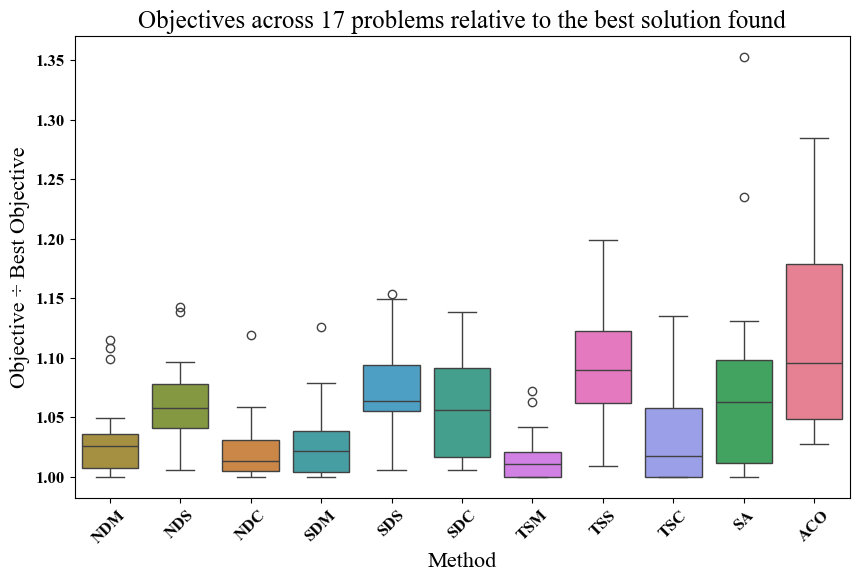

In [6]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
import seaborn as sns
import matplotlib.pyplot as plt

# Example: df with columns ['prob_id', 'method', 'best_obj']
# df = pd.read_csv("your_results.csv")

df = df_heur_orig.copy()

# 1️⃣ Pivot so each row = problem, each column = method
df_filt = df[df['method'] != 0][df['method'] != 0]#[df['best_obj'] < 10000]
df_filt['method'] = df_filt['method'].map({0: "NDS1", 1: "NDS", 2: "NDM", 3: "SDM", 4: "NDC", 5: "SDS", 6: "TSM", 7: "TSS", 8: "SA", 9: "TSC", 10: "ACO", 11:"SDC"})
pivot = df_filt.pivot(index='problem_id', columns='method', values='best_obj')

relative = pivot.div(pivot.min(axis=1), axis=0)
# font = {'family': 'sans-serif', 
#         'weight' : 'bold',
#         'size'   : 36}

# plt.rc('font', **font)
# plt.rcParams.update({
#     "text.usetex": True,     # enables LaTeX rendering
#     "font.family": "serif",    # use a serif font
#     "font.serif": ["Computer Modern"]  # closest to Overleaf
# })
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})
plt.figure(figsize=(10, 6))
sns.boxplot(data=relative, order=['NDM', 'NDS', 'NDC', 'SDM', 'SDS', 'SDC', 'TSM', 'TSS', 'TSC', 'SA', 'ACO'])
plt.xticks(rotation=45, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.xlabel("Method", fontsize=16)
# # plt.xlabel('')
plt.ylabel("Objective ÷ Best Objective", fontsize=16)
plt.title("Objectives across 17 problems relative to the best solution found", fontsize=18)
plt.show()

In [7]:
records = []
with open("final_heur_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_orig = pd.DataFrame(records)
# display(df_orig)

In [8]:
records = []
with open("final_mip_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            # d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_mip_orig = pd.DataFrame(records)
df_mip_orig["bound_gap"] = (df_mip_orig["best_obj"]-df_mip_orig["best_bound"])/df_mip_orig["best_bound"]*100
# display(df_mip_orig[df_mip_orig['problem_id'].isin([28, 29, 31])])
# display(df_mip_orig)

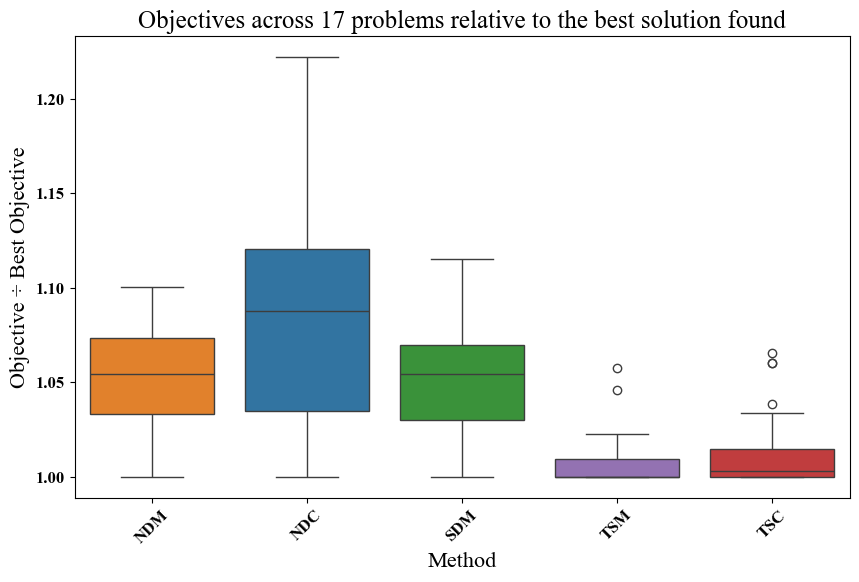

In [9]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
import seaborn as sns
import matplotlib.pyplot as plt

# Example: df with columns ['prob_id', 'method', 'best_obj']
# df = pd.read_csv("your_results.csv")

df = df_orig.copy()

# 1️⃣ Pivot so each row = problem, each column = method
df_filt = df[df['method'] != 100][df['method'] != 0]#[df['best_obj'] < 10000]
df_filt['method'] = df_filt['method'].map({0: "NDS1", 1: "NDS", 2: "NDM", 3: "SDM", 4: "NDC", 5: "SDS", 6: "TSM", 7: "TSS", 8: "SA", 9: "TSC", 10: "ACO", 11:"SDC"})
pivot = df_filt.pivot(index='problem_id', columns='method', values='best_obj')

relative = pivot.div(pivot.min(axis=1), axis=0)
# font = {'family': 'sans-serif', 
#         'weight' : 'bold',
#         'size'   : 36}

# plt.rc('font', **font)
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],
#     "axes.unicode_minus": False,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42
# })
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Times"],  # LaTeX-compatible Times font
#     "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}"  # high-quality Times font
# })
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})
plt.figure(figsize=(10, 6))
sns.boxplot(data=relative, order=['NDM', 'NDC', 'SDM', 'TSM', 'TSC'])
plt.xticks(rotation=45, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.xlabel("Method", fontsize=16)
# # plt.xlabel('')
plt.ylabel("Objective ÷ Best Objective", fontsize=16)
plt.title("Objectives across 17 problems relative to the best solution found", fontsize=18)
plt.show()

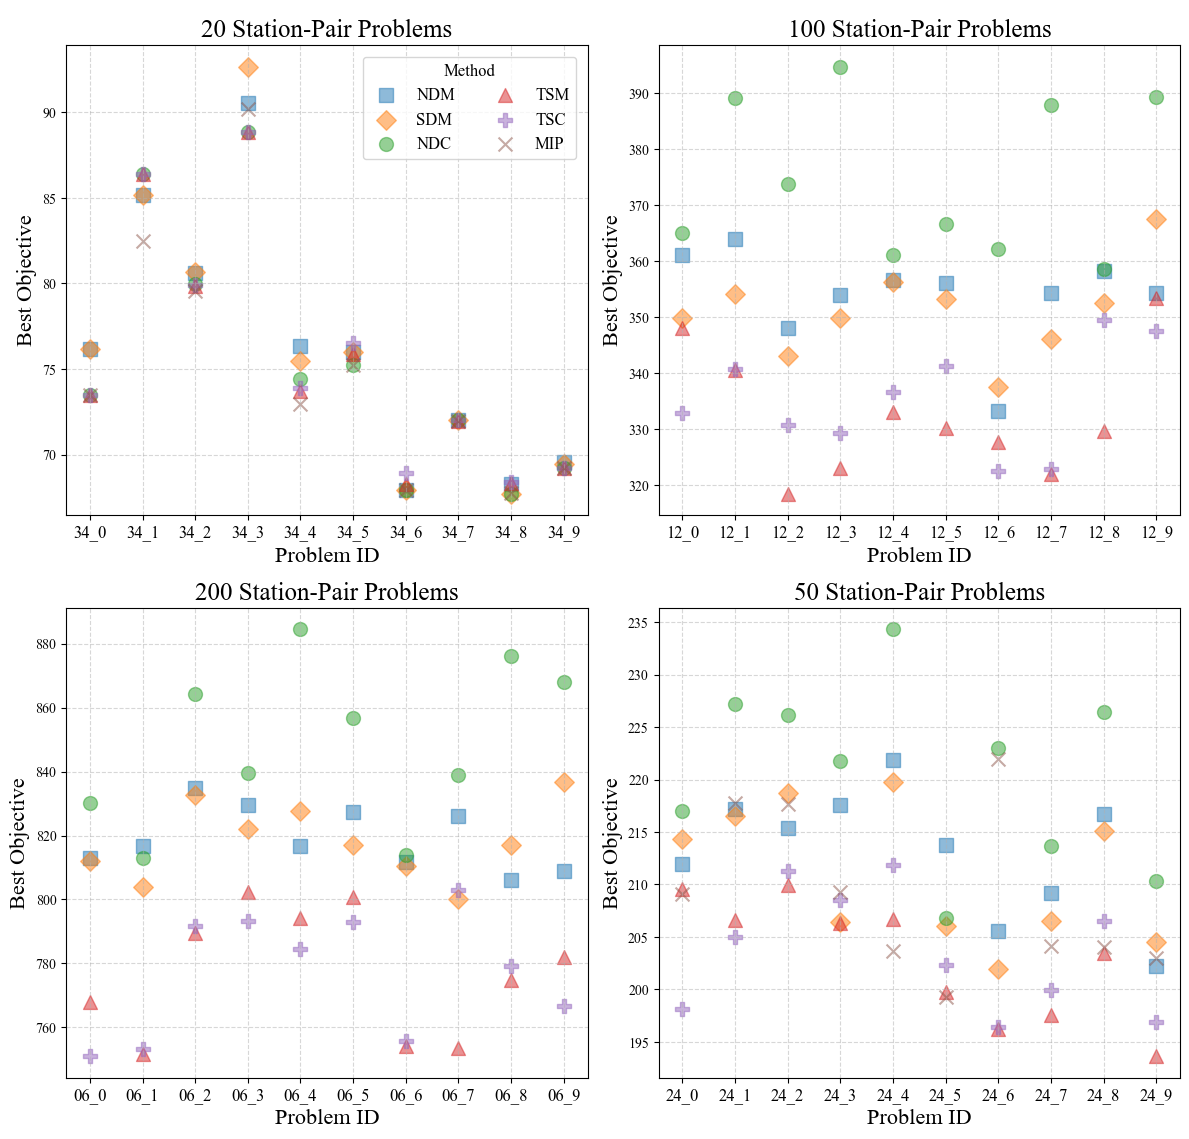

In [10]:

df_heur = df_orig.copy()
df_mip = df_mip_orig.copy()
df_mip['method'] = -1
df = pd.concat([df_heur, df_mip[df_mip['best_obj'] > 0]])
df['method'] = df['method'].map({-1: 'MIP', 2: "NDM", 3: "SDM", 4: "NDC", 6: "TSM", 9: "TSC"})

markers = {
    'NDC': 'o',   # circle
    'NDM': 's',   # square
    'TSM': '^',   # triangle up
    'TSC': 'P',   # diamond
    'SDM': 'D',   # x
    'MIP': 'x'
}
# plt.rcParams.update({
#     "text.usetex": True,     # enables LaTeX rendering
#     "font.family": "serif",    # use a serif font
#     "font.serif": ["Computer Modern"]  # closest to Overleaf
# })
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})
# for pid in [['34', '24'], ['12', '06']]:#, ['00']]:
# for pid in ['34', '24', '12', '06']:#, ['00']]:
#     plt.figure(figsize=(6,6))
#     order = [f"{pid}_{i}" for i in range(10)]
#     plt.tight_layout()
#     group = df[df['problem_id'].astype(str).str.startswith(pid)] # | df['problem_id'].astype(str).str.startswith(pid[1])]
    
#     # loop through each method only once
#     for method in group["method"].unique():
#         df0 = group[group["method"] == method]
#         plt.scatter(
#         [order.index(p) for p in df0["problem_id"]],  # numeric positions
#         df0["best_obj"],
#         marker=markers.get(str(method), 'o'),
#         label=str(method),
#         alpha=0.5,
#         s=100
#     )
    
#       # desired order
#     plt.xticks(ticks=range(len(order)), labels=order, fontsize=12)
#     plt.title(f"Best objectives for {group['num_stations'].values[0]//2} station-pair problems", fontsize=18)
#     plt.xlabel("Problem ID", fontsize=16)
#     plt.ylabel("Best Objective (hrs)", fontsize=16)
#     # plt.xticks(fontsize=12)
#     plt.xticks(fontsize=12)
#     plt.legend(title="Method", loc="upper left", ncol=1, fontsize=12, title_fontsize=12, bbox_to_anchor=(1, 1))
# #     plt.legend(, loc='upper left', borderaxespad=0.)
# # plt.tight_layout()
    
#     plt.show()
pids = ['24', '12', '06', '34']
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()  # Flatten to easily loop over

for i, pid in enumerate(pids):
    if i == 0:
        i = 3
    elif i == 3:
        i = 0
    ax = axes[i]
    order = [f"{pid}_{j}" for j in range(10)]
    group = df[df['problem_id'].astype(str).str.startswith(pid)]
    
    # loop through each method only once
    for method in group["method"].unique():
        df0 = group[group["method"] == method]
        ax.scatter(
            [order.index(p) for p in df0["problem_id"]],
            df0["best_obj"],
            marker=markers.get(str(method), 'o'),
            label=str(method),
            alpha=0.5,
            s=100
        )

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, fontsize=12)
    ax.set_title(f"{group['num_stations'].values[0]//2} Station-Pair Problems", fontsize=18)
    ax.set_xlabel("Problem ID", fontsize=16)
    ax.set_ylabel("Best Objective", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)

# Add one legend for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc=[0.305, 0.86], ncol=2, fontsize=12, title_fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
